### **DA3_Data_Analysis_Notebook**

You will work on real VSDI images  obtained from the primary somatosensory cortex from the rat

I invite you to read the following paper 
**[Grinvald (2004) VSDI a new era in functional imaging of cortical dynamics](http://wexler.free.fr/library/files/grinvald%20(2004)%20vsdi.%20a%20new%20era%20in%20functional%20imaging%20of%20cortical%20dynamics.pdf)**

and **Corbo et al. (2018)  in the documents folder of this repository**


**Description of the experiment :** 

In the anasthetized rat, you are interested in studying the dynamic of tactile evoked responses in the primary somatosensory cortex.

Brief tactile stimulations (duration of a stimulus = 20 ms) were randomly applied on the finger tip (digit 2,3,4 or 5) of the rat forehand, about 1 stimulus per 20 second. 

Emitted VSDI fluorescence was recorded. During a trial, one image was acquired every 3 ms, 256 times. One trial = 256 images each 3ms then 768 ms of duration for a trial.

As usual, like for **any imaging method**, one has to **compare a 'test' trial (with stimulus) to a control trial**

Alternatively, stimulation and control trials were acquired. 

A file can contain data from a stimulation trial or a control trial (acquisition of the same amount of images without tactile stimulation)

For example the file named T1-B2R10-0419-616 contains the images of a trial with a stimulation while the file named T1-B2R10-0419-617 contains control images with stimulation (acquisition of the same amount of images without tactile stimulation).


During a trial with stimulation, the stimulus was applied 100 ms after beginning of image acquisition. The stimulus was then applied at frame (image) 33. 


Each file named "T1-B2R10-0419-..." contains the same variable:

- **Evok** : Fluorescence signal for the 10 000 pixels of each 256 images of one acquisition (10 000 pixels $*$ 256 images)
            
            
The file MANIP120419_2 contains : 

- **Block** : stimulus of the list of trial



### **Starting**

First step, 
**Drop all the needed file into your main directory**

**Just run the following section** in order to open and convert the lists Evok into a 100 pixels $*$ 100 pixels $*$ 256 images array, for a stimulus trial and a control trial, to open the file containing the identification of the trial (which finger had been stimulated) and to open cortex image

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os


if os.getcwd().endswith('scripts'):
    os.chdir('..')
os.getcwd()


'd:\\DATA\\Projets\\DA3_VSDI_S1_G2_2026'

In [46]:
# HERE we open the file containing the condition file list

DataUnit=loadmat('data/MANIP120419_2') 
DataUnit.keys()
ListCond=DataUnit["block"][0]


In [47]:


fileIDinit=616
trialID=1
fileID=fileIDinit+2*trialID-2

##Open files and converted into a 100 pixels * 100 pixels * 256 images array
Data=loadmat('data/T'+str(trialID)+'-B2R10-0419-'+str(fileID))  

print('Size Evok : ' + str(Data['Evok'].shape))
Stim=Data["Evok"].reshape((100,100,255))
print('Size Stim : ' + str(Stim.shape))


Size Evok : (10000, 255)
Size Stim : (100, 100, 255)


Size Control : (100, 100, 255)


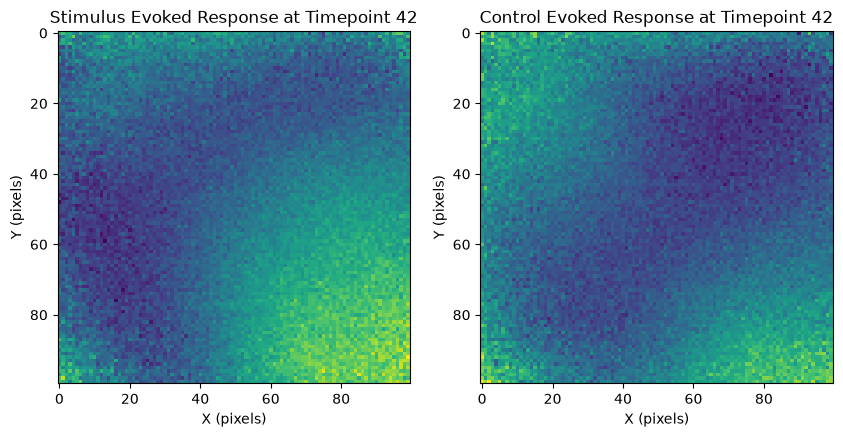

Size Cortex : (100, 100, 3)


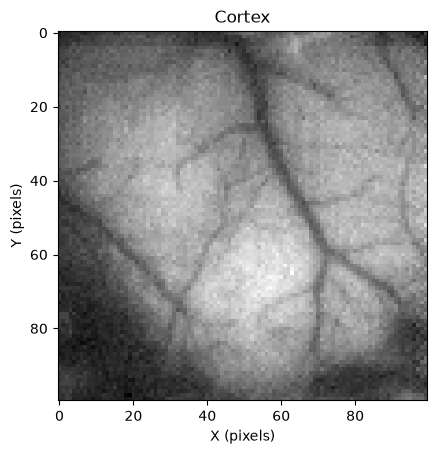

In [48]:


Data=loadmat('data/T'+str(trialID)+'-B2R10-0419-'+str(fileID+1))  
Control=Data["Evok"].reshape((100,100,255))
print('Size Control : ' + str(Control.shape))
timepoint = 42

figure, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(Stim[:,:,timepoint])
ax[0].set_xlabel('X (pixels)')
ax[0].set_ylabel('Y (pixels)')
ax[0].set_title(f'Stimulus Evoked Response at Timepoint {timepoint}')
ax[1].imshow(Control[:,:,timepoint])
ax[1].set_xlabel('X (pixels)')
ax[1].set_ylabel('Y (pixels)')
ax[1].set_title(f'Control Evoked Response at Timepoint {timepoint}')

plt.show()


Cortex=loadmat('data/GREEN_MANIP120419')  
Cortex=Cortex['gr']
print('Size Cortex : ' + str(Cortex.shape))

plt.imshow(Cortex)
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.title('Cortex')

plt.show()


*Stim* is now a 3D matrix of 100 $*$ 100 $*$ 256. 256 images of 100 $*$ 100 pixels.

Same applies for *Control*

Then *Stim[:,:,0]* is the first image of *Stim*.
*Stim[50,50,:]* will give you the signal over time for the pixel in the center of the image.

**To do list:**

* Visualize the image 40 of the *stim* trial and the image 40 of the *control* trial (use imshow)  
* For one choosen pixel, plot the signal (fluorescence F) as a function of time (from 0 to 256 images) for the stim trial and the control trial on the same plot with different color 
* Explain why it is important to compare both. 
* Calculate a new 3DArray with is the result of (Stim-Control)/Control. This ratio called  ***DF/F***. 
* For one choosen pixel, plot the *DF/F* as a function of time (from 0 to 256 images) 
* Visualize the image 40 of *DF/F* 
* Using a gaussian filter, filter the images  (function : gaussian_filter), visualize the image 40 of *DF/F* filtered with a kernel of 2,3,4 and 5 (make a subplot of 1 line and 4 plots) 
* On one figure, show on the 2 rows (subplot(2,10)) 
    *  10 following *DF/F*  non filtered images (image 37 to 46) on one row
    *  10 following *DF/F*  filtered images (image 37 to 46) on a second row
* plot the *DF/F* as a function of time for a pixel located the region of activation and plot on the same axes, the mean *DF/F* of a group of pixel (ROI : region of interest)  



**RAW images**

**Visualize the image 40 of the stim trial and the image 40 of the control trial (use imshow)** - 2 min - 

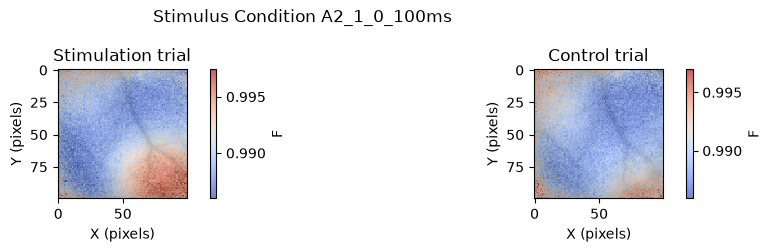

In [49]:
### image to see one out of 256 frame = image n° x

frame=40

fig = plt.figure( figsize=(10,4))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
pos1=ax1.imshow(Cortex,alpha=1)
pos2=ax2.imshow(Cortex,alpha=1)
pos1=ax1.imshow(Stim[:,:,frame], cmap='coolwarm', interpolation='none',alpha=0.7)
pos2=ax2.imshow(Control[:,:,frame], cmap='coolwarm', interpolation='none',alpha=0.7)


ax1.set_xlabel('X (pixels)'),ax2.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)'),ax2.set_ylabel('Y (pixels)')
ax1.set_title('Stimulation trial'),ax2.set_title('Control trial')
fig.colorbar(pos1, ax=ax1,label='F')
fig.colorbar(pos2, ax=ax2,label='F')
fig.suptitle('Stimulus Condition ' +ListCond[2*trialID-2][0])
plt.tight_layout()

**Compute DF/F and plot RAW signal vs DF/F**

**For one choosen pixel, plot the signal (fluorescence F) as a function of time (from 0 to 256 images) for the stim trial and the control trial on the same plot with different color** 
**Explain why it is important to compare both.**

**Calculate a new 3DArray with is the result of (Stim-Control)/Control. This ratio called DF/F.** 

**For one choosen pixel, plot the DF/F as a function of time (from 0 to 256 images)** 

**Visualize the image 40 of *DF/F*** 


**Using a gaussian filter, filter the images  (function : gaussian_filter), visualize the image 40 of *DF/F* filtered with a kernel of 2,3,4 and 5 (make a subplot of 1 line and 4 plots)** 

#### **Filter the images with gaussians filter**

Define the Sigma depending on the level of filtering 

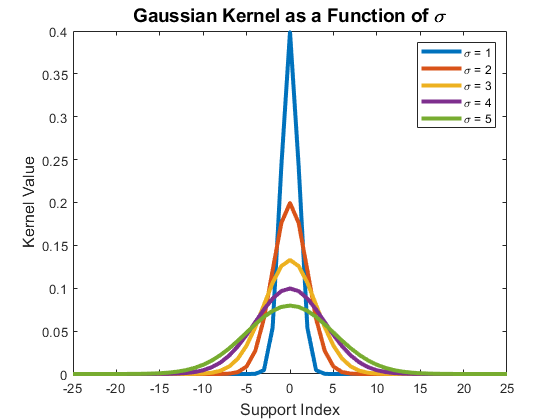

**Plot the *DF/F* as a function of time for a pixel located the region of activation and plot on the same axes, the mean *DF/F* of a group of pixel (ROI : region of interest)  - 15 min -**